# XGBoost — Quarterly Expanding Window (5-Day Gap)

**Target**: `target_excess_xfn_5d`  |  **Window**: Expanding  |  **Gap**: 5 td  
**Features**: 15 simple/explainable  |  **Cadence**: Quarterly (~63 td per fold)

In [1]:
import sys
import warnings
import pickle
import json
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import f1_score
from IPython.display import display

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[2]
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments_archive'
for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'ROOT: {ROOT}')

ROOT: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis


In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import STRIDE_EVAL

df = load_dataset()

def call_decay_from_days(days, halflife=20.0):
    return np.exp(-days.clip(lower=0).fillna(999.0) / halflife)

call_decay = call_decay_from_days(df['days_since_call'])
df['evt_exec_tone']         = df[['transcript_ceo_prep_sentiment_mean_ffill',
                                   'transcript_cfo_prep_sentiment_mean_ffill']].mean(axis=1) * call_decay
df['evt_guidance_topic']     = df['topic_guidance_share_ffill'] * call_decay
df['evt_guidance_sentiment'] = df['topic_guidance_sentiment_ffill'] * call_decay
df['evt_aml_topic']          = df['topic_regulatory_AML_share_ffill'] * call_decay
df['evt_aml_sentiment']      = df['topic_regulatory_AML_sentiment_ffill'] * call_decay

FEATURES = [
    'td_return_5d', 'td_return_20d', 'td_vs_xfn_5d', 'td_dist_52w_high',
    'news_sent_mean_30d', 'news_count_30d', 'days_since_last_news',
    'days_since_call', 'is_earnings_week',
    'evt_exec_tone', 'evt_framing_gap',
    'evt_guidance_topic', 'evt_guidance_sentiment',
    'evt_aml_topic', 'evt_aml_sentiment',
]
TARGET    = 'target_excess_xfn_5d'
THRESHOLD = 0.003
LABEL_MAP = {-1: 0, 0: 1, 1: 2}
INV_MAP   = {0: -1, 1: 0, 2: 1}
STRIDE    = STRIDE_EVAL
GAP_DAYS  = 5   # no-touch buffer: target_excess_xfn_5d uses 5-day forward returns

missing = [f for f in FEATURES if f not in df.columns]
assert not missing, f'Missing: {missing}'
print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Features: {len(FEATURES)}')
print(f'Gap between train_end and test_start: {GAP_DAYS} trading days (target leakage prevention)')

Loaded 1285 rows  |  2021-02-25 to 2026-04-09
Features: 15
Gap between train_end and test_start: 5 trading days (target leakage prevention)


## 1. Define Quarterly Folds (5-Day Gap Applied)

In [3]:
def make_quarterly_expanding_folds(df, target, min_train_days=504, quarter_days=63, gap=GAP_DAYS):
    '''
    Expanding-window quarterly folds.
    gap: trading-day buffer between train_end and test_start to prevent
         label leakage from the 5-day forward return target.
    train ends gap days before test starts; test window = ~1 quarter.
    '''
    dated = df[df[target].notna()].sort_values('date')
    dates = dated['date'].values
    folds = []
    # i = index of first test day; train ends at i-1-gap
    i, fold_id = min_train_days + gap, 1
    while i < len(dates):
        te_end_i      = min(i + quarter_days - 1, len(dates) - 1)
        train_end_idx = i - 1 - gap          # last safe training day
        folds.append((
            fold_id,
            str(dates[0])[:10],              # train_start (always beginning)
            str(dates[train_end_idx])[:10],  # train_end (gap days before test)
            str(dates[i])[:10],              # test_start
            str(dates[te_end_i])[:10],       # test_end
        ))
        i = te_end_i + 1
        fold_id += 1
    return folds

FOLDS = make_quarterly_expanding_folds(df, TARGET)

print(f'Total quarterly folds: {len(FOLDS)}')
print(f'Gap applied: {GAP_DAYS} trading days between train_end and test_start')
print(f'{"Fold":<6} {"Train start":<13} {"Train end":<13} {"Test start":<13} {"Test end":<13} {"Gap":>5} {"Test rows":>9}')
print('-' * 72)
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    dated_te = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    gap_days = (pd.Timestamp(te_s) - pd.Timestamp(tr_e)).days
    print(f'{fold_id:<6} {tr_s:<13} {tr_e:<13} {te_s:<13} {te_e:<13} {gap_days:>5} {len(dated_te):>9}')

Total quarterly folds: 13
Gap applied: 5 trading days between train_end and test_start
Fold   Train start   Train end     Test start    Test end        Gap Test rows
------------------------------------------------------------------------
1      2021-02-25    2023-02-28    2023-03-08    2023-06-06        8        63
2      2021-02-25    2023-05-30    2023-06-07    2023-09-06        8        63
3      2021-02-25    2023-08-29    2023-09-07    2023-12-05        9        63
4      2021-02-25    2023-11-28    2023-12-06    2024-03-07        8        63
5      2021-02-25    2024-02-29    2024-03-08    2024-06-06        8        63
6      2021-02-25    2024-05-30    2024-06-07    2024-09-06        8        63
7      2021-02-25    2024-08-29    2024-09-09    2024-12-05       11        63
8      2021-02-25    2024-11-28    2024-12-06    2025-03-10        8        63
9      2021-02-25    2025-03-03    2025-03-11    2025-06-09        8        63
10     2021-02-25    2025-06-02    2025-06-10    2

## 2. Hyperparameter Grid Search

In [4]:
import xgboost as xgb

def fit_xgb(train_df, test_df, params):
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([LABEL_MAP[v] for v in y_tr], dtype=int)
    clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3,
                            random_state=42, n_jobs=1, verbosity=0, **params)
    clf.fit(x_tr, y_enc)
    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds     = np.array([INV_MAP[int(p)] for p in clf.predict(x_te)])
    return clf, preds, y_te_cls, y_te_cont

print('fit_xgb defined.')

fit_xgb defined.


In [5]:
def offset_metrics(preds, y_true_cls, y_true_cont):
    rows = []
    for off in range(STRIDE):
        idx = np.arange(off, len(preds), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows).mean()

print('offset_metrics defined.')

offset_metrics defined.


In [6]:
n_folds    = len(FOLDS)
tune_start = max(2, n_folds // 4)
tune_end   = min(n_folds - 2, n_folds * 3 // 4)
TUNE_FOLDS = FOLDS[tune_start : tune_end + 1]
print(f'Tuning on folds {tune_start+1}..{tune_end+1} ({len(TUNE_FOLDS)} folds) out of {n_folds} total')

GRID = {
    'max_depth':          [3, 4, 6],
    'min_child_weight':   [1, 5, 10],
    'n_estimators':       [80, 150, 250],
    'learning_rate':      [0.05],
    'subsample':          [0.8],
    'colsample_bytree':   [0.8],
    'reg_alpha':          [0.2],
    'reg_lambda':         [1.0],
    'tree_method':        ['hist'],
}

from itertools import product as iproduct
param_combos = list(iproduct(GRID['max_depth'], GRID['min_child_weight'], GRID['n_estimators']))
print(f'Grid size: {len(param_combos)} configs x {len(TUNE_FOLDS)} tuning folds')

search_rows = []
for md, mcw, ne in param_combos:
    params = dict(max_depth=md, min_child_weight=mcw, n_estimators=ne,
                  learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.2, reg_lambda=1.0, tree_method='hist')
    fold_metrics = []
    for fold_id, tr_s, tr_e, te_s, te_e in TUNE_FOLDS:
        train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                      (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
        test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                      (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
        if len(test_df) < 10:
            continue
        _, preds, y_cls, y_cont = fit_xgb(train_df, test_df, params)
        fold_metrics.append(offset_metrics(preds, y_cls, y_cont))
    if not fold_metrics:
        continue
    agg = pd.DataFrame(fold_metrics).mean()
    search_rows.append({'max_depth': md, 'min_child_weight': mcw, 'n_estimators': ne,
                        'active_asa': agg['active_asa'], 'macro_f1': agg['macro_f1'],
                        'active_cov': agg['active_cov'],
                        'composite': 0.6 * agg['active_asa'] + 0.4 * agg['macro_f1']})

search_df = pd.DataFrame(search_rows).sort_values('composite', ascending=False)
best_row  = search_df.iloc[0]
BEST_PARAMS = dict(max_depth=int(best_row.max_depth), min_child_weight=int(best_row.min_child_weight),
                   n_estimators=int(best_row.n_estimators),
                   learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                   reg_alpha=0.2, reg_lambda=1.0, tree_method='hist')
print('=== Top-5 configs ===')
display(search_df.head(5).round(4))
print(f'\nBest params: {BEST_PARAMS}')
print(f'Best composite: {best_row.composite:.4f}')

Tuning on folds 4..10 (7 folds) out of 13 total
Grid size: 27 configs x 7 tuning folds


=== Top-5 configs ===


,max_depth,min_child_weight,n_estimators,active_asa,macro_f1,active_cov,composite
15,4,10,80,0.5262,0.3029,0.9841,0.4368
24,6,10,80,0.5204,0.3104,0.9683,0.4364
6,3,10,80,0.5271,0.2972,0.9954,0.4351
22,6,5,150,0.5108,0.3090,0.9427,0.4301
16,4,10,150,0.5086,0.3046,0.9614,0.4270



Best params: {'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 80, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'tree_method': 'hist'}
Best composite: 0.4368


## 3. Full Walk-Forward Evaluation

In [7]:
fold_results       = []
fold_models        = []
fold_x_te_list     = []
fold_sv_out_list   = []
fold_sv_under_list = []
fold_shap_out_dfs   = []
fold_shap_under_dfs = []

print('Running full walk-forward on all quarterly folds...')
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                  (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    if len(test_df) < 5:
        continue

    clf, preds, y_cls, y_cont = fit_xgb(train_df, test_df, BEST_PARAMS)
    m = offset_metrics(preds, y_cls, y_cont)

    explainer = shap.TreeExplainer(clf)
    x_te_cl   = test_df[FEATURES].fillna(train_df[FEATURES].median())
    sv = explainer.shap_values(x_te_cl)
    if isinstance(sv, list):
        sv_out, sv_under = sv[2], sv[0]
    else:
        sv_arr = np.array(sv)
        if sv_arr.ndim == 3 and sv_arr.shape[-1] == 3:
            sv_out, sv_under = sv_arr[:, :, 2], sv_arr[:, :, 0]
        else:
            sv_out = sv_under = sv_arr

    fold_sv_out_list.append(sv_out)
    fold_sv_under_list.append(sv_under)
    fold_x_te_list.append(x_te_cl.reset_index(drop=True))
    fold_shap_out_dfs.append(pd.Series(np.abs(sv_out).mean(axis=0), index=FEATURES, name=fold_id))
    fold_shap_under_dfs.append(pd.Series(np.abs(sv_under).mean(axis=0), index=FEATURES, name=fold_id))

    fold_results.append({'fold': fold_id, 'train_rows': len(train_df), 'test_rows': len(test_df),
                          'train_end': tr_e, 'test_start': te_s, 'test_end': te_e, **m.to_dict()})
    fold_models.append(clf)
    print(f'Fold {fold_id:>2}  acc={m["mean_acc"]:.3f}  asa={m["active_asa"]:.3f}  cov={m["active_cov"]:.3f}')

results_df = pd.DataFrame(fold_results).set_index('fold')
print(f'\nDone. {len(results_df)} folds evaluated.')

Running full walk-forward on all quarterly folds...
Fold  1  acc=0.301  asa=0.395  cov=0.795
Fold  2  acc=0.463  asa=0.615  cov=0.936


Fold  3  acc=0.474  asa=0.661  cov=0.983
Fold  4  acc=0.399  asa=0.472  cov=0.983
Fold  5  acc=0.491  asa=0.594  cov=0.983


Fold  6  acc=0.492  asa=0.689  cov=0.968
Fold  7  acc=0.400  asa=0.445  cov=0.969
Fold  8  acc=0.365  asa=0.413  cov=1.000


Fold  9  acc=0.382  asa=0.453  cov=0.985
Fold 10  acc=0.428  asa=0.618  cov=1.000
Fold 11  acc=0.414  asa=0.509  cov=1.000


Fold 12  acc=0.427  asa=0.541  cov=0.969
Fold 13  acc=0.200  asa=0.400  cov=1.000

Done. 13 folds evaluated.


## 4. Performance Summary

=== Per-Fold Performance ===


,train_rows,test_rows,mean_acc,macro_f1,active_cov,active_asa
fold,,,,,,
1,504,63,0.301,0.234,0.795,0.395
2,567,63,0.463,0.329,0.936,0.615
3,630,63,0.474,0.361,0.983,0.661
4,693,63,0.399,0.283,0.983,0.472
5,756,63,0.491,0.335,0.983,0.594
6,819,63,0.492,0.392,0.968,0.689
7,882,63,0.400,0.282,0.969,0.445
8,945,63,0.365,0.242,1.000,0.413
9,1008,63,0.382,0.250,0.985,0.453



=== Aggregate (mean across all folds) ===
  Mean accuracy   : 0.403
  Macro F1        : 0.295
  Active coverage : 0.967
  Active ASA      : 0.523
  Composite       : 0.4321  (0.6xASA + 0.4xF1)
  DirAcc_strict    : 0.507
  DirAcc_abstain50 : 0.524


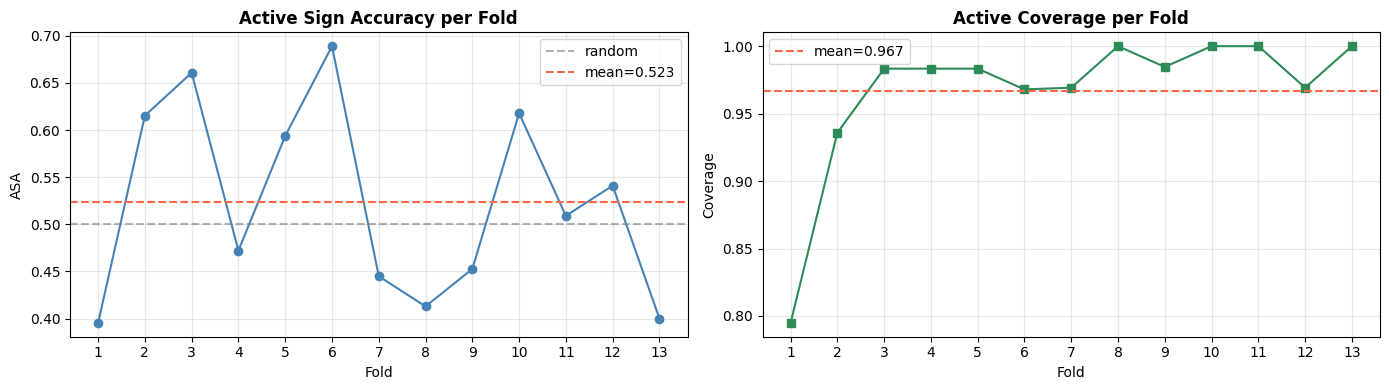

In [8]:
display_cols = ['train_rows', 'test_rows', 'mean_acc', 'macro_f1', 'active_cov', 'active_asa']

print('=== Per-Fold Performance ===')
display(results_df[display_cols].round(3))

means = results_df[display_cols].mean()
composite = 0.6 * means['active_asa'] + 0.4 * means['macro_f1']
print('\n=== Aggregate (mean across all folds) ===')
print(f'  Mean accuracy   : {means["mean_acc"]:.3f}')
print(f'  Macro F1        : {means["macro_f1"]:.3f}')
print(f'  Active coverage : {means["active_cov"]:.3f}')
print(f'  Active ASA      : {means["active_asa"]:.3f}')
print(f'  Composite       : {composite:.4f}  (0.6xASA + 0.4xF1)')

results_df['DirAcc_strict']    = results_df['active_asa'] * results_df['active_cov']
results_df['DirAcc_abstain50'] = (results_df['active_asa'] * results_df['active_cov']
                                   + 0.5 * (1 - results_df['active_cov']))
print(f'  DirAcc_strict    : {results_df["DirAcc_strict"].mean():.3f}')
print(f'  DirAcc_abstain50 : {results_df["DirAcc_abstain50"].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(results_df.index.astype(str), results_df['active_asa'], marker='o', color='steelblue')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='random')
axes[0].axhline(results_df['active_asa'].mean(), color='tomato', linestyle='--',
                label=f'mean={results_df["active_asa"].mean():.3f}')
axes[0].set_title('Active Sign Accuracy per Fold', fontweight='bold')
axes[0].set_ylabel('ASA'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(results_df.index.astype(str), results_df['active_cov'], marker='s', color='seagreen')
axes[1].axhline(results_df['active_cov'].mean(), color='tomato', linestyle='--',
                label=f'mean={results_df["active_cov"].mean():.3f}')
axes[1].set_title('Active Coverage per Fold', fontweight='bold')
axes[1].set_ylabel('Coverage'); axes[1].legend(); axes[1].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('Fold')

plt.tight_layout()
plt.show()

## 5. SHAP Global Importance & Fold Stability

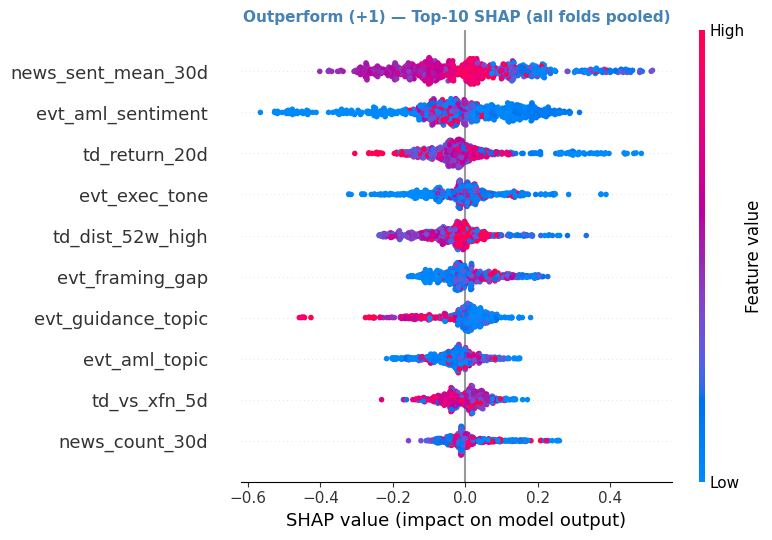

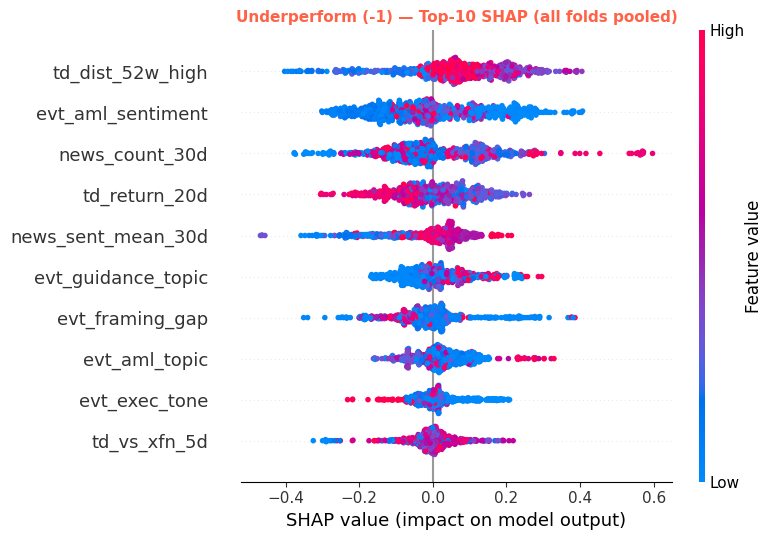

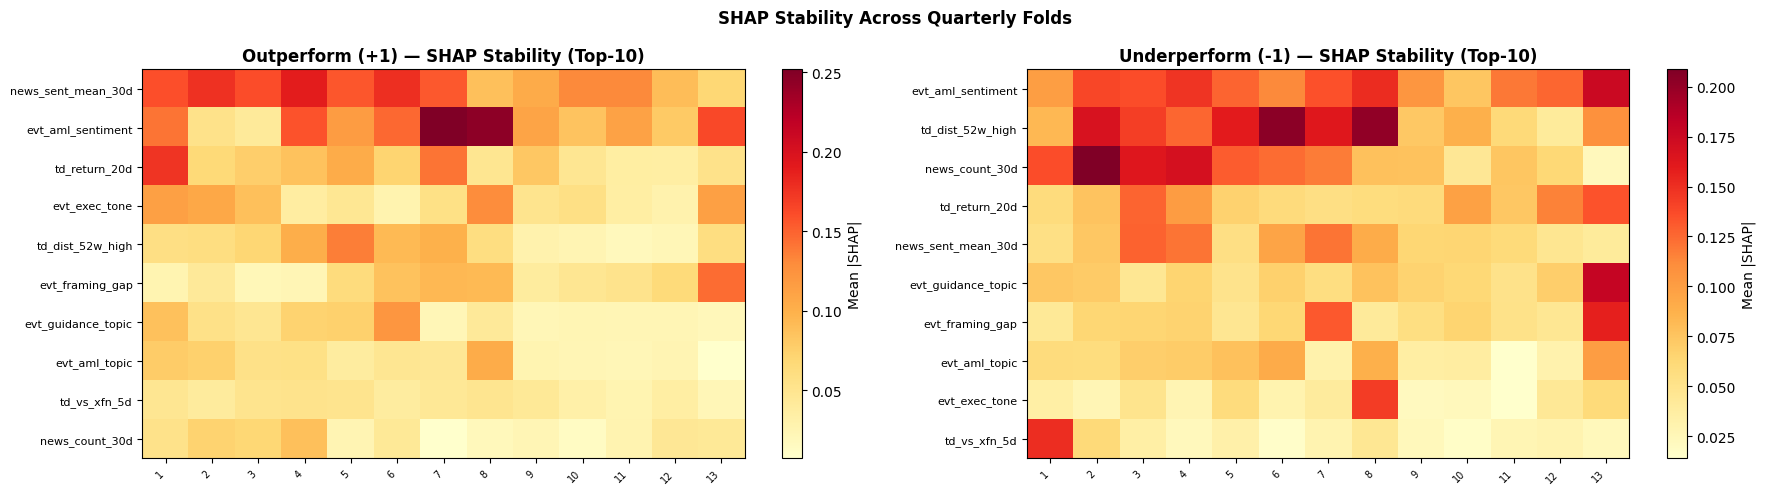

Top-10 Outperform:
news_sent_mean_30d    0.1375
evt_aml_sentiment     0.1314
td_return_20d         0.0789
evt_exec_tone         0.0688
td_dist_52w_high      0.0642
evt_framing_gap       0.0614
evt_guidance_topic    0.0492
evt_aml_topic         0.0465
td_vs_xfn_5d          0.0411
news_count_30d        0.0410

Top-10 Underperform:
evt_aml_sentiment     0.1266
td_dist_52w_high      0.1243
news_count_30d        0.1081
td_return_20d         0.0830
news_sent_mean_30d    0.0779
evt_guidance_topic    0.0717
evt_framing_gap       0.0688
evt_aml_topic         0.0585
evt_exec_tone         0.0441
td_vs_xfn_5d          0.0393


In [9]:
df_shap_out   = pd.DataFrame(fold_shap_out_dfs)
df_shap_under = pd.DataFrame(fold_shap_under_dfs)
imp_out   = df_shap_out.mean().sort_values(ascending=False)
imp_under = df_shap_under.mean().sort_values(ascending=False)

all_sv_out   = np.vstack(fold_sv_out_list)
all_sv_under = np.vstack(fold_sv_under_list)
all_x_te     = pd.concat(fold_x_te_list, ignore_index=True)

for sv_all, imp_cls, label, color in [
    (all_sv_out,   imp_out,   'Outperform (+1)',   'steelblue'),
    (all_sv_under, imp_under, 'Underperform (-1)', 'tomato'),
]:
    top10 = imp_cls.head(10).index.tolist()
    idx   = [FEATURES.index(f) for f in top10]
    plt.figure(figsize=(12, 6))
    shap.summary_plot(sv_all[:, idx], all_x_te[top10], feature_names=top10,
                      plot_type='dot', max_display=10, show=False, color_bar=True)
    plt.title(f'{label} — Top-10 SHAP (all folds pooled)', fontsize=11,
              fontweight='bold', color=color)
    plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, df_cls, imp_cls, label in [
    (axes[0], df_shap_out,   imp_out,   'Outperform (+1)'),
    (axes[1], df_shap_under, imp_under, 'Underperform (-1)'),
]:
    top  = imp_cls.head(10).index.tolist()
    heat = df_cls[top].T
    im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([str(c) for c in heat.columns], rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top, fontsize=8)
    ax.set_title(f'{label} — SHAP Stability (Top-10)', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.suptitle('SHAP Stability Across Quarterly Folds', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('Top-10 Outperform:');  print(imp_out.head(10).round(4).to_string())
print('\nTop-10 Underperform:'); print(imp_under.head(10).round(4).to_string())

## 6. Save Artifact

In [10]:
TODAY       = date.today().isoformat()
ARTIFACT_ID = f'xgb_quarterly_expanding-{TODAY}'
PKL_PATH    = ARTIFACT_DIR / f'{ARTIFACT_ID}.pkl'
JSON_PATH   = ARTIFACT_DIR / f'{ARTIFACT_ID}.json'

means     = results_df[['mean_acc','macro_f1','active_cov','active_asa']].mean()
composite = float(0.6 * means['active_asa'] + 0.4 * means['macro_f1'])

artifact = {
    'features':           FEATURES,
    'target':             TARGET,
    'threshold':          THRESHOLD,
    'label_map':          LABEL_MAP,
    'inverse_label_map':  INV_MAP,
    'best_params':        BEST_PARAMS,
    'window_type':        'expanding_quarterly',
    'gap_days':           GAP_DAYS,
    'n_folds_evaluated':  len(results_df),
    'performance_summary': {
        'mean_acc':   float(means['mean_acc']),
        'macro_f1':   float(means['macro_f1']),
        'active_cov': float(means['active_cov']),
        'active_asa': float(means['active_asa']),
        'composite':  composite,
    },
}
with open(PKL_PATH, 'wb') as f:
    pickle.dump(artifact, f)

meta = {
    'artifact_id':        ARTIFACT_ID,
    'model_name':         'xgb_quarterly_expanding',
    'window_type':        'expanding_quarterly',
    'gap_days':           GAP_DAYS,
    'created':            TODAY,
    'best_params':        BEST_PARAMS,
    'features':           FEATURES,
    'target':             TARGET,
    'threshold':          THRESHOLD,
    'n_folds_evaluated':  int(len(results_df)),
    'performance_summary': artifact['performance_summary'],
}
with open(JSON_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved: {PKL_PATH.name}')
print(f'Saved: {JSON_PATH.name}')
print(f'Composite score: {composite:.4f}')
print(f'Gap applied    : {GAP_DAYS} trading days')

Saved: xgb_quarterly_expanding-2026-04-23.pkl
Saved: xgb_quarterly_expanding-2026-04-23.json
Composite score: 0.4321
Gap applied    : 5 trading days
